In [89]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
G = ox.load_graphml("tests/data/test_rng.ml")
nodes = ox.graph_to_gdfs(G, edges=False, node_geometry=False)
nodes.head(2)

,y,x,street_count,highway
osmid,,,,
290700344,56.162667,93.360388,2,NaN
290700348,56.162327,93.359660,2,NaN


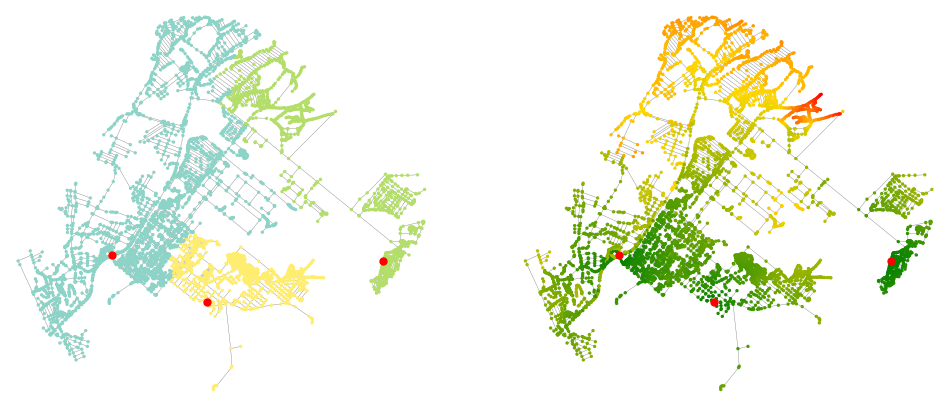

In [40]:
def voronoi_forest(G, sources, path_function, cutoff=None, weight='travel_time', routes_return=False):

    # Расчет
    times, routes = path_function(G, sources=sources, cutoff=cutoff, weight=weight)
    times = pd.Series(times, dtype=float)

    # Определение стартового узла для каждого маршрута
    if isinstance(sources, dict):
        nearest = pd.Series({k:sources[route[0]] for k, route in routes.items()}, dtype=str)
    else:
        nearest = pd.Series({k:route[0] for k, route in routes.items()}, dtype='int64')

    # Построение леса
    # times_forest = {s:{k:v} for s,k,v in zip(nearest, times.items())}

    if routes_return:
        routes = pd.Series(routes)
        return nearest, times, routes
    else:
        return nearest, times


#===========================================================================================
print('0', end='\r')
ndl = list(G.nodes())
# start_points = [ndl[100], ndl[2000], ndl[3000]]
start_points = {ndl[100]:'A', 
                ndl[2000]:'B', 
                ndl[3000]:'C'}
nearest, times = voronoi_forest(G, start_points, nx.multi_source_dijkstra)


print('1', end='\r')
nx.set_node_attributes(G, nearest, 'nearest')
nx.set_node_attributes(G, times, 'route_time')


print('2', end='\r')
locations = start_points

nds = ox.graph_to_gdfs(G, edges=False)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
nds.loc[locations.keys()].plot(ax=ax1, markersize=25, color='red')

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
nds.loc[locations.keys()].plot(ax=ax2, markersize=25, color='red')

plt.show()

In [4]:
@staticmethod
def cover_index(
            ip_val=10):
    '''
    Расчет индекса прикрытия.

    Аргументы
    ---------
    `ip_val`:int
        Пороговое значение для определения индекса прикрытия.
        Рекомендуется использовать 10 для городских населенных пунктов и 
        20 для сельских.

    Возвращает
    ----------
    `metric_val`: float
        Значение целевой метрики

    Пример
    ------
    Вызывается как результат выполнения функции с заданными параметрами:

    для расчета ИП-10:
        `calc_ip()` или `calc_ip(ip_val=10)`
    для расчета ИП-20:
        `calc_ip(ip_val=20)`
    '''
    def _cover_index(route_times:pd.Series):
        '''Расчет индекса прикрытия.

        Аргументы
        ---------
        `route_times`:pd.Series
            Серия данных о временах прибытия в узлы ГДС 
            (или вообще произвольных данных о временах прибытия)
        '''
        if not isinstance(route_times, pd.Series):
            raise TypeError(
                "Аргумент route_times может быть только типа pd.Series"
                )

        tot_len = len(route_times)
        if tot_len==0:
            return 0
        ip_len = sum(route_times<=ip_val)
        return 100*ip_len/tot_len

    return _cover_index

# Расчет метрик для всего результата
metrics = {}
metrics['mean_arr_time'] = np.mean(times)
metrics['max_arr_time'] = np.max(times)
metrics['median_arr_time'] = np.median(times)

metrics['ip5'] = cover_index(5)(times)
metrics['ip10'] = cover_index()(times)
metrics['ip20'] = cover_index(20)(times)

print(pd.Series(metrics))

mean_arr_time       6.509977
max_arr_time       22.958373
median_arr_time     5.383067
ip5                46.838663
ip10               75.581395
ip20               99.691134
dtype: float64


In [5]:
# Расчет метрик для каждого из подразделений
for start_point in nearest.unique():
    times_part = pd.Series([t for n,t in zip(nearest, times) if n==start_point], dtype=times.dtype)
    print(start_point)
    metrics = {}
    metrics['mean_arr_time'] = np.mean(times_part)
    metrics['max_arr_time'] = np.max(times_part)
    metrics['median_arr_time'] = np.median(times_part)

    metrics['ip5'] = cover_index(5)(times_part)
    metrics['ip10'] = cover_index()(times_part)
    metrics['ip20'] = cover_index(20)(times_part)

    print(pd.Series(metrics))
    print(' ')

A
mean_arr_time        6.382747
max_arr_time        15.874785
median_arr_time      5.493972
ip5                 45.509893
ip10                77.960426
ip20               100.000000
dtype: float64
 
B
mean_arr_time       8.787579
max_arr_time       22.958373
median_arr_time    10.331133
ip5                29.421353
ip10               49.470253
ip20               98.614507
dtype: float64
 
C
mean_arr_time        4.114145
max_arr_time         7.456096
median_arr_time      3.963406
ip5                 72.782258
ip10               100.000000
ip20               100.000000
dtype: float64
 


In [88]:
def nodes_metric(G, sources, path_function, metric_function, voronoi_function, cutoff=None, weight='travel_time', **kwargs):
    _, times = voronoi_function(G=G, sources=sources, path_function=path_function, cutoff=cutoff, weight=weight, **kwargs)
    return metric_function(times)


start_points = {ndl[100]:'A', 
                ndl[2000]:'B', 
                ndl[3000]:'C'}
# start_points = [ndl[100]]
nodes_metric(G, start_points, nx.multi_source_dijkstra, metric_function=np.mean, voronoi_function=voronoi_forest)

6.509977493498235

In [60]:
poly = gpd.read_file("tests/data/test_polygon.gpkg")
G = ox.load_graphml("tests/data/test_rng.ml")

In [57]:
def voronoi_forest_for_points(points, **kwargs):
    results = voronoi_forest(**kwargs)
    
    r_out=[]
    for r in results:
        val = dict(filter( lambda x: x[0] in points, r.items()))
        r_out.append(pd.Series(val))
    return r_out

In [82]:
def voronoi_forest_for_area(area, **kwargs):
    # print(kwargs['G'].graph.get('crs'))

    if not area.crs == G.graph.get('crs'):
        raise ValueError(f'Системы координат полигона `area` ({area.crs}) и `графа` G ({G.graph.get("crs")}) не совпадают!')

    nodes = ox.graph_to_gdfs(kwargs['G'], edges=False)
    points = nodes[nodes.within(area.iloc[0].geometry)]
    points = list(points.index)
    # print(points)

    return voronoi_forest_for_points(points=points, **kwargs)


# ======== Проверка ========================
nearest, times = voronoi_forest_for_area(G=G, 
                                        sources=start_points,
                                        path_function=nx.multi_source_dijkstra,
                                        area=poly)
nearest

2760591335    C
2760591341    C
5574240371    C
5703333240    C
1644098164    A
             ..
4116035750    A
4116035751    A
4116035752    A
4116035977    A
4116035978    A
Length: 2237, dtype: object

In [62]:
nodes = ox.graph_to_gdfs(G, edges=False)
nodes

,y,x,street_count,highway,geometry
osmid,,,,,
290700344,56.162667,93.360388,2,NaN,POINT (93.36039 56.16267)
290700348,56.162327,93.359660,2,NaN,POINT (93.35966 56.16233)
290700352,56.161600,93.358188,2,NaN,POINT (93.35819 56.16160)
290700353,56.161100,93.356967,2,NaN,POINT (93.35697 56.16110)
290700355,56.159615,93.352813,2,NaN,POINT (93.35281 56.15962)
...,...,...,...,...,...
10861562817,56.123782,93.301762,4,NaN,POINT (93.30176 56.12378)
10861562818,56.123778,93.302198,4,NaN,POINT (93.30220 56.12378)
10861562819,56.123544,93.304071,3,NaN,POINT (93.30407 56.12354)


In [65]:
nearest.name = 'nearest'
nodes = nodes.join(nearest)

ax = nodes[nodes['nearest'].notna()].plot(markersize=1)
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax)
poly.boundary.plot(ax=ax, color='r')

In [84]:
def nodes_metric(G, sources, path_function, metric_function, voronoi_function, cutoff=None, weight='travel_time', **kwargs):
    _, times = voronoi_function(G=G, sources=sources, path_function=path_function, cutoff=cutoff, weight=weight, **kwargs)
    return metric_function(times)

nodes_metric(G, start_points, nx.multi_source_dijkstra,
             metric_function=np.mean,
             voronoi_function=voronoi_forest_for_area,
             area=poly)

4.2880732710581775

In [85]:
nodes_metric(G, start_points, nx.multi_source_dijkstra,
             metric_function=np.mean,
             voronoi_function=voronoi_forest)

6.509977493498235

# Тест готовых функций

In [93]:
from genesis.optimal_service_areas import voronoi_forest, voronoi_forest_for_area
from genesis.swiss_knife import MSF

In [94]:
area = gpd.read_file("tests/data/test_polygon.gpkg")
G = ox.load_graphml("tests/data/test_rng.ml")

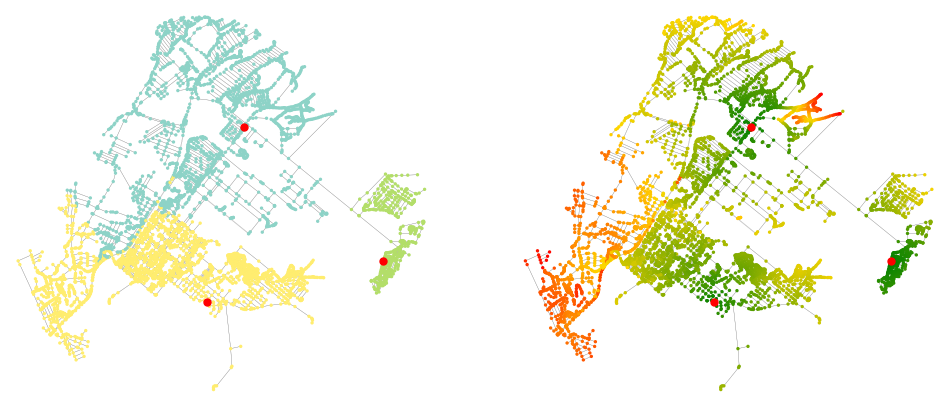

In [92]:
print('0', end='\r')
ndl = list(G.nodes())
# start_points = [ndl[1000], ndl[2000], ndl[3000]]
start_points = {ndl[1000]:'A', 
                ndl[2000]:'B', 
                ndl[3000]:'C'}
nearest, times = voronoi_forest(G, start_points, nx.multi_source_dijkstra)


print('1', end='\r')
nx.set_node_attributes(G, nearest, 'nearest')
nx.set_node_attributes(G, times, 'route_time')


print('2', end='\r')
locations = start_points

nds = ox.graph_to_gdfs(G, edges=False)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
nds.loc[locations.keys()].plot(ax=ax1, markersize=25, color='red')

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
nds.loc[locations.keys()].plot(ax=ax2, markersize=25, color='red')

plt.show()

<Axes: >

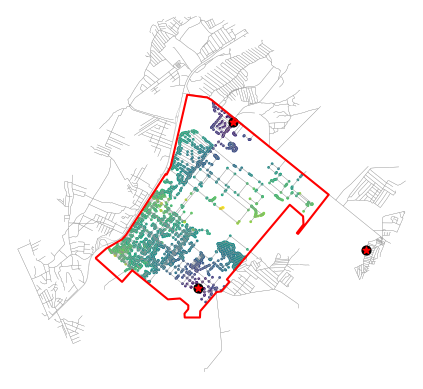

In [100]:
# РАсчет параметров прибытия
nearest, times = voronoi_forest_for_area(G=G, 
                                         sources=start_points, 
                                         path_function=MSF,
                                         area=area)

# Получение итогового геодатафрейма
nodes = ox.graph_to_gdfs(G, edges=False)
nearest.name = 'nearest'
nodes = nodes.join(nearest)
times.name = 'route_times'
nodes = nodes.join(times)


# Печать карты
ax = nodes[nodes['nearest'].notna()].plot(markersize=1, column='route_times')
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax)
poly.boundary.plot(ax=ax, color='r')
nodes.loc[locations.keys()].plot(ax=ax, markersize=40, color='k')
nodes.loc[locations.keys()].plot(ax=ax, markersize=25, color='red', marker="*")

# Тестирование логирования

In [1]:
import logging

In [2]:
logging.debug("A DEBUG Message")
logging.info("An INFO")
logging.warning("A WARNING")
logging.error("An ERROR")
logging.critical("A message of CRITICAL severity")

ERROR:root:An ERROR
CRITICAL:root:A message of CRITICAL severity


In [4]:
logging.basicConfig(level=logging.INFO, filename="py_log.log",filemode="w")
logging.debug("A DEBUG Message")
logging.info("An INFO")
logging.warning("A WARNING")
logging.error("An ERROR")
logging.critical("A message of CRITICAL severity")

ERROR:root:An ERROR
CRITICAL:root:A message of CRITICAL severity
